In [23]:
import pandas as pd

# Evaluation on Non-Metazoan and Unreviewed Data Sets
both of these have an intact signal peptide.

## Non-Metazoan
(keyword:KW-0800) AND (reviewed:true) AND (date_created:[* TO 2026-03-03]) NOT (taxonomy_id:33208)

```bash
uv run toxfam predict non_metazoan \
  --model-dir model/model_output/combined_run \
  --toxicity-only \
  -o benchmark/non_metazoan/predict/combined_toxicity.tsv
   Resolved dataset 'non_metazoan' -> non_metazoan.tsv
```

In [24]:
non_metazoan_df = pd.read_csv("../benchmark/non_metazoan/predict/combined_toxicity.tsv", sep='\t')
non_metazoan_df.head()

,identifier,p_toxic,predicted_toxic
0,A0A0H2US87,0.011873,False
1,A0A0H3AIG7,0.118866,False
2,A0A0H3NK84,0.001348,False
3,A0A1S4NYE3,0.028274,False
4,A0A218N034,0.000010,False


In [25]:
non_metazoan_df["predicted_toxic"].value_counts()

predicted_toxic
False    548
True     264
Name: count, dtype: int64

<Axes: >

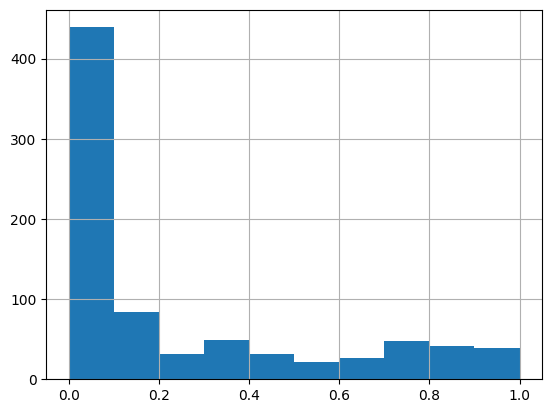

In [26]:
non_metazoan_df["p_toxic"].hist()


## Unreviewed
(keyword:KW-0800) AND (reviewed:false) AND (taxonomy_id:33208) AND (fragment:false) AND (date_created:[* TO 2026-06-10])

```bash
uv run toxfam predict unreviewed \
  --model-dir model/model_output/combined_run \
  -o benchmark/unreviewed/predict/combined.tsv
```

In [27]:
unreviewed_df = pd.read_csv("../benchmark/unreviewed/predict/combined.tsv", sep='\t')
unreviewed_input = pd.read_csv("../data/evaluation/unreviewed/unreviewed.tsv", sep='\t')

print("Input columns: ",unreviewed_input.columns)
unreviewed_df.head()

Input columns:  Index(['Entry', 'Organism', 'Protein families', 'Sequence', 'Organism (ID)'], dtype='object')


,identifier,pred_1,conf_1,pred_2,conf_2,pred_3,conf_3,p_toxic,predicted_toxic
0,A0A4Y2G8R1,nontox,0.998813,Peptidase S1 family,0.000351,Venom metalloproteinase (M12B) family,0.000324,0.001187,False
1,A0A670IWD1,nontox,0.841922,other,0.042451,Insulin family,0.018022,0.158078,False
2,A0A670J0E7,nontox,0.556936,Venom metalloproteinase (M12B) family,0.414533,Disintegrin family,0.009423,0.443064,True
3,A0A670K065,other,0.939281,nontox,0.055751,Limacoditoxin family,0.000599,0.944249,True
4,A0A670K3I7,other,0.949134,nontox,0.046272,Limacoditoxin family,0.000560,0.953728,True


In [28]:
# add unreviewed input "Protein families" column as "Uniprot Assignments" right after the identifier column, based on "Entry"
unreviewed_df.insert(1, "Uniprot Assignments", unreviewed_df["identifier"].map(unreviewed_input.set_index("Entry")["Protein families"]))
unreviewed_df.head()

,identifier,Uniprot Assignments,pred_1,conf_1,pred_2,conf_2,pred_3,conf_3,p_toxic,predicted_toxic
0,A0A4Y2G8R1,NOTCH family,nontox,0.998813,Peptidase S1 family,0.000351,Venom metalloproteinase (M12B) family,0.000324,0.001187,False
1,A0A670IWD1,Endothelin/sarafotoxin family,nontox,0.841922,other,0.042451,Insulin family,0.018022,0.158078,False
2,A0A670J0E7,NaN,nontox,0.556936,Venom metalloproteinase (M12B) family,0.414533,Disintegrin family,0.009423,0.443064,True
3,A0A670K065,Nucleotide pyrophosphatase/phosphodiesterase f...,other,0.939281,nontox,0.055751,Limacoditoxin family,0.000599,0.944249,True
4,A0A670K3I7,Nucleotide pyrophosphatase/phosphodiesterase f...,other,0.949134,nontox,0.046272,Limacoditoxin family,0.000560,0.953728,True
